In [41]:
import camelot
import io
import pdfplumber
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from PIL import Image
from image_extractor import print_image_summary, extract_images_hybrid_method, show_single_image
from identifier import predict_logo, setup_data_generators

In [9]:
pdf_file = 'bactochem/archive/yarkon_33.pdf'

In [10]:
tables = camelot.read_pdf(pdf_file,pages='all')

In [11]:
model = load_model('lab_logo_classifier.h5')

In [12]:
images = extract_images_hybrid_method(pdf_file)
print_image_summary(images)


Extracted 9 images:
------------------------------------------------------------
Page  1 | Image 0 |  591x 839 | Format: jpeg
Page  1 | Image 1 |  321x 104 | Format: png
Page  6 | Image 0 |   80x  76 | Format: jpeg
Page  6 | Image 2 |   64x  63 | Format: jpeg
Page  6 | Image 3 |  105x  55 | Format: jpeg
Page  6 | Image 4 |   68x  67 | Format: jpeg
Page  7 | Image 0 |  566x  65 | Format: png
Page  8 | Image 0 |  566x  65 | Format: png
Page  9 | Image 0 |  566x  65 | Format: png

Images per page:
Page 1: 2 images
Page 6: 4 images
Page 7: 1 images
Page 8: 1 images
Page 9: 1 images


In [33]:
# show_single_image(images[0])
# images[0].save_image('figure_no1.png')

In [14]:
page_dict = {}

for i, img in enumerate(images):
    image = Image.open(io.BytesIO(img.image_data))
    page = images[i].page_number
    try:
        image.save(f'figure_no{i}.png')
    except OSError:
        pass        
    
    class_names, confidence = predict_logo(model, image, ['ALS', 'Bactochem', 'Aminolab', 'ALS','Yeda', 'Yeda'])
    print(f'figure no.{i}, in page {page}, is related to class: {class_names}, with {confidence:.2f} confidence')
    
    # Check if this page already exists in dictionary
    if page not in page_dict:
        # First entry for this page
        page_dict[page] = [class_names, confidence]
    else:
        # Page already exists, check if current confidence is higher
        if confidence > page_dict[page][1]:
            page_dict[page] = [class_names, confidence]

# Print the final dictionary
print("\nFinal Page Dictionary:")
for page_num in sorted(page_dict.keys()):
    lab, conf = page_dict[page_num]
    print(f"{page_num}: ['{lab}', np.float32({conf:.2f})]")
        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
figure no.0, in page 1, is related to class: Yeda, with 0.90 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
figure no.1, in page 1, is related to class: Yeda, with 0.66 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
figure no.2, in page 6, is related to class: ALS, with 0.61 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
figure no.3, in page 6, is related to class: ALS, with 0.48 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
figure no.4, in page 6, is related to class: ALS, with 0.65 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
figure no.5, in page 6, is related to class: ALS, with 0.43 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
figure no.6, in page 7, is related to class: ALS, with 0.75 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
figure no.7, in page 8, is related to class: ALS, with 0.75 confidence
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
figure no.8, in page 9, is related to class: ALS, with 0.75 confidence

Final Page Dicti

In [15]:
lab = 'ALS'
lst_page_lab = [i for i in page_dict.keys() if page_dict.get(i)[0] == lab] 
p = ",".join(str(item) for item in lst_page_lab)
tables = camelot.read_pdf(pdf_file,
                          pages=p,
                          flavor='stream',
                          table_areas=['30,30,400,700'],
                          split_text=True            # Split text within cells
                         )

In [253]:
from functions import read_file
dfs = [tables[i].df for i in range(tables.n)]

In [265]:
dfs[4]

,0,1,2,3,4,5,6,7,8
0,Parameter,,,Method,LOR,Unit,,Result,MU
1,Polycyclic Aromatics,Hydrocar,bons (P,AHs) - Continued,,,,,
2,Acenaphthylene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
3,Acenaphthene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
4,Fluorene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
5,Phenanthrene,,,W-SMVGMS05,0.020,µg/L,,<0.020,----
6,Anthracene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
7,Fluoranthene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
8,Pyrene,,,W-SMVGMS05,0.010,µg/L,,0.010,± 30.0%
9,Benz(a)anthracene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----


In [286]:
import pandas as pd

# Create empty DataFrame with proper structure
df_all = pd.DataFrame(columns=['test','units', 'value'])

for df_file in dfs:
    try:
        df = read_file(df_file)  # Your file reading function
        
        # Check if DataFrame is empty
        if df.empty:
            print(f"Warning: {df_file} is empty, skipping...")
            continue
        
        # Use positional indexing based on column count
        if len(df.columns) == 6:
            # Keep columns at positions 0, 3, 4
            df = df.iloc[:, [0, 3, 4]]
        elif len(df.columns) == 9:
            # Keep columns at positions 0, 5, 7
            df = df.iloc[:, [0, 5, 7]]
        else:
            print(f"Warning: {df_file} has {len(df.columns)} columns (expected 6 or 9), skipping...")
            continue
        
        # Set standardized column names
        df.columns = ['test','units', 'value']
        
        # Concatenate to main DataFrame
        df_all = pd.concat([df_all, df], ignore_index=True)
        
        print(f"Processed {df_file}: {df.shape[0]} rows added")
        print(df.head())
        
    except Exception as e:
        print(f"Error processing {df_file}: {str(e)}")
        continue

# Clean up: Remove any completely empty rows
df_all = df_all.dropna(how='all').reset_index(drop=True)

print(f"\nFinal combined DataFrame shape: {df_all.shape}")
print(f"Total rows: {len(df_all)}")

0           Work Order      :          PR2239520                        
1             Customer      :            KTE Co.                        
2              Contact      :       Eyal Shvartz                        
3              Address      :                                           
4                                  Hameginim Ave    . 53                
5                                  3326518 Haifa  Israel                
6               E-mail      :     eyal@kte.co.il                        
7            Telephone      :               ----                        
8              Project      :         KTE-198-22                        
9                                                                       
10        Order number      :         KTE-198-22                        
11                                                                      
12                                                                      
13                Site      :   Gilad 6 Tel Aviv   

In [287]:
df_all.to_csv('almog.csv')

In [274]:
dfs[4]

,0,1,2,3,4,5,6,7,8
0,Parameter,,,Method,LOR,Unit,,Result,MU
1,Polycyclic Aromatics,Hydrocar,bons (P,AHs) - Continued,,,,,
2,Acenaphthylene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
3,Acenaphthene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
4,Fluorene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
5,Phenanthrene,,,W-SMVGMS05,0.020,µg/L,,<0.020,----
6,Anthracene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
7,Fluoranthene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----
8,Pyrene,,,W-SMVGMS05,0.010,µg/L,,0.010,± 30.0%
9,Benz(a)anthracene,,,W-SMVGMS05,0.010,µg/L,,<0.010,----


## test

In [127]:
pdf_file = 'Aminolab/Lido_Ashdod_09_09_2025.PDF'
tables = camelot.read_pdf(pdf_file,
                          pages='6',
                          flavor='stream',
                          table_areas= ['30,110,460,680'],
                          row_tol = 7
                         )

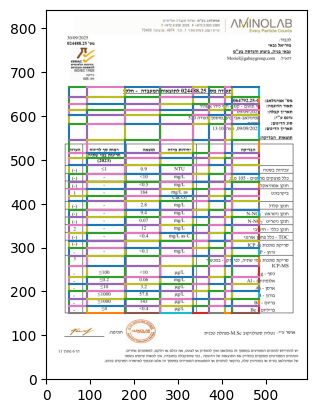

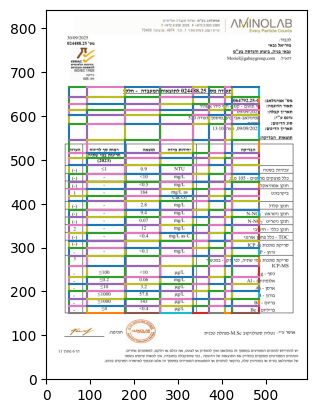

In [128]:
camelot.plot(tables[0], 'grid')

In [121]:
tables[0].df

,0,1,2
0,"1,1,2,2-Tetrachloroethane",79 - 34 - 5,<5
1,"1,2,3-Trichloropropane",96 - 18 - 4,<5
2,"1,2-Dibromo-3-chloropropane",96 - 12 - 8,<0.03
3,"1,2-Dichlorobenzene *",95- 50- 1,<5
4,"1,3-Dichloropropane",142-28-9,<5
5,"1,4-Dichlorobenzene",106 - 46 - 7,<5
6,"2,2 dichloropropane",594- 20- 7,<5
7,2-Chlorotoluene,95 - 49 - 8,<5
8,4-Chlorotoluene,106 - 43 - 4,<5
9,Benzene,71 -43 -2,<0.5
